# ScamRadar+ — Evaluation Notebook

Presentation layer over the evaluation-phase artifacts produced by the
production pipeline. Every metric shown below is loaded from a persisted
artifact under `outputs/eval/` or `models/`; no evaluation is re-run here.

**University requirements covered.**
- **Model Evaluation** — predefined criteria, ranked candidates, primary
  decision metric, conclusions and discovered issues (§4–§9, §11–§12).
- **Evaluation Process Documentation** — experiments performed, model
  variants evaluated, hyperparameters tested, values selected,
  performance tables and graphs, hyperparameter tuning trajectory,
  final evaluation on unseen data (§5–§10).
- **Evaluation Deliverables** — justified final model selection, saved
  best-model artifact, summary table, graphs and visualisations
  (§3, §5, §9–§11, §13).


## 0. Setup


In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import roc_curve, precision_recall_curve

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.figsize'] = (10, 4.5)

FORCE_REBUILD = False   # flip to True to re-run build_evaluation_summary

# ─── Repo root discovery ─────────────────────────────────────────────────
NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR
for _ in range(6):
    if (REPO_ROOT / 'models' / 'e7_p1_variants').exists() and (REPO_ROOT / 'api').exists():
        break
    REPO_ROOT = REPO_ROOT.parent
else:
    raise RuntimeError(f'Could not locate ScamRadar+ repo root from {NB_DIR}')

# ─── Paths ───────────────────────────────────────────────────────────────
SUMMARY_SCRIPT   = 'scripts/evaluation/build_evaluation_summary.py'

MASTER_JSON      = REPO_ROOT / 'outputs' / 'eval' / 'master_summary.json'
MASTER_CSV       = REPO_ROOT / 'outputs' / 'eval' / 'master_summary.csv'
FINDINGS_MD      = REPO_ROOT / 'outputs' / 'eval' / 'e8p9_findings.md'

BAKEOFF_JSON     = REPO_ROOT / 'outputs' / 'eval' / 'e8p9_bakeoff_results.json'
BAKEOFF_CSV      = REPO_ROOT / 'outputs' / 'eval' / 'e8p9_bakeoff_results.csv'
E7P1_RESULTS     = REPO_ROOT / 'outputs' / 'eval' / 'e7_p1_results.json'
E8P9_PER_ITEM    = REPO_ROOT / 'outputs' / 'eval' / 'e8p9_per_item.parquet'
E5_METADATA      = REPO_ROOT / 'models' / 'e5_metadata.json'
E5_THRESHOLD_SWEEP = REPO_ROOT / 'models' / 'e5_threshold_sweep.json'
E8P9_BUNDLE      = REPO_ROOT / 'models' / 'e7_p1_variants' / 'e7_p1_full_e8p9.joblib'

# ─── Sibling reports directory (E2/E3/E4 evidence) ───────────────────────
SR2_REPORTS_CANDIDATES = [
    REPO_ROOT / 'data_pipeline' / 'reports',
    Path.home() / 'Downloads' / 'scamradar2' / 'reports',
]
for c in SR2_REPORTS_CANDIDATES:
    if (c / 'e2_ranking.json').exists():
        SR2_REPORTS = c
        break
else:
    SR2_REPORTS = None

E2_RANKING = SR2_REPORTS / 'e2_ranking.json' if SR2_REPORTS else None
E3_RANKING = SR2_REPORTS / 'e3_ranking.json' if SR2_REPORTS else None
E4_TRIALS  = SR2_REPORTS / 'e4_trials.json'  if SR2_REPORTS else None

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f'Repo root         : {REPO_ROOT}')
print(f'Master summary    : {MASTER_JSON}   (exists={MASTER_JSON.exists()})')
print(f'Bake-off results  : {BAKEOFF_JSON}  (exists={BAKEOFF_JSON.exists()})')
print(f'E8-P9 per-item    : {E8P9_PER_ITEM} (exists={E8P9_PER_ITEM.exists()})')
print(f'E8-P9 bundle      : {E8P9_BUNDLE}   (exists={E8P9_BUNDLE.exists()})')
print(f'SR2 reports       : {SR2_REPORTS}')
print(f'FORCE_REBUILD     : {FORCE_REBUILD}')


Repo root         : /Users/ameer/Downloads/ScamRadar
Master summary    : /Users/ameer/Downloads/ScamRadar/outputs/eval/master_summary.json   (exists=True)
Bake-off results  : /Users/ameer/Downloads/ScamRadar/outputs/eval/e8p9_bakeoff_results.json  (exists=True)
E8-P9 per-item    : /Users/ameer/Downloads/ScamRadar/outputs/eval/e8p9_per_item.parquet (exists=True)
E8-P9 bundle      : /Users/ameer/Downloads/ScamRadar/models/e7_p1_variants/e7_p1_full_e8p9.joblib   (exists=True)
SR2 reports       : /Users/ameer/Downloads/scamradar2/reports
FORCE_REBUILD     : False


In [2]:
# ─── Cache-aware helper (identical to DP / DU / Modeling notebooks) ─────
def cached_step(name: str, outputs, build_fn):
    outs = outputs if isinstance(outputs, list) else [outputs]
    missing = [o for o in outs if not o.exists()]
    print(f'── {name} ──')
    if not FORCE_REBUILD and not missing:
        for o in outs:
            print(f'  ✓ cached  {o}   ({o.stat().st_size / 1024:.1f} KB)')
        return
    if FORCE_REBUILD:
        print('  ⟳ FORCE_REBUILD — running from scratch')
    else:
        print(f'  → building (missing: {[str(m) for m in missing]})')
    t0 = time.time()
    build_fn()
    dt = time.time() - t0
    still_missing = [o for o in outs if not o.exists()]
    if still_missing:
        raise RuntimeError(f'Build failed; still missing: {still_missing}')
    for o in outs:
        print(f'  ✓ built   {o}   ({o.stat().st_size / 1024:.1f} KB)')
    print(f'  time: {dt:.1f}s')


PY = sys.executable

def run_repo_script(script_rel: str):
    subprocess.run([PY, script_rel], cwd=str(REPO_ROOT), check=True)


## 1. Consolidated evaluation artifacts

The `build_evaluation_summary` script is an aggregator: it reads the
persisted evaluation JSONs from every stage of the modelling programme
plus the E8-P9 per-item benchmark parquet, and emits three synthesis
outputs. It does not retrain, re-score, or recompute anything.


In [3]:
def build_summary():
    run_repo_script(SUMMARY_SCRIPT)


cached_step('Build consolidated evaluation artifacts',
            [MASTER_JSON, MASTER_CSV, FINDINGS_MD],
            build_summary)


── Build consolidated evaluation artifacts ──
  ✓ cached  /Users/ameer/Downloads/ScamRadar/outputs/eval/master_summary.json   (8.7 KB)
  ✓ cached  /Users/ameer/Downloads/ScamRadar/outputs/eval/master_summary.csv   (2.4 KB)
  ✓ cached  /Users/ameer/Downloads/ScamRadar/outputs/eval/e8p9_findings.md   (7.4 KB)


In [4]:
master = json.loads(MASTER_JSON.read_text())
print(f'Generated at         : {master["generated_at"]}')
print(f'Primary decision     : {master["primary_decision_metric"]}')
print(f'Stages summarised    : {len(master["stages"])}')
print(f'Deployed model family: {master["deployed_model"]["classifier_family"]}')


Generated at         : 2026-08-10T03:05:35.485974+00:00
Primary decision     : external PR-AUC at deployed threshold 0.59
Stages summarised    : 7
Deployed model family: LogisticRegression


## 2. The deployed model

The final selected classifier is a Logistic Regression trained on the
concatenation of word TF-IDF, character TF-IDF, and 25 standardised
engineered numerical features. The complete card below is the source of
truth for what the production inference pipeline loads at runtime.


In [5]:
dm = master['deployed_model']

print('┌─ DEPLOYED MODEL CARD ────────────────────────────────────────────────┐')
print(f'  Artifact             : {dm["artifact_path"]}')
print(f'  Classifier family    : {dm["classifier_family"]}')
print(f'  Operating threshold  : {dm["operating_threshold"]}')
print(f'  Feature-matrix dim   : {dm["feature_matrix_dim"]:,}')
print(f'  Classifier size      : {dm["classifier_size_mb"]:.2f} MB')
print(f'  Batch-1 latency (ms) : {dm["latency_batch1_ms_median"]:.3f}')
print('├─ HYPERPARAMETERS (E4 Optuna best) ───────────────────────────────────┤')
for k, v in dm['hyperparameters'].items():
    print(f'  {k:22s} : {v}')
print('└──────────────────────────────────────────────────────────────────────┘')


┌─ DEPLOYED MODEL CARD ────────────────────────────────────────────────┐
  Artifact             : models/e7_p1_variants/e7_p1_full_e8p9.joblib
  Classifier family    : LogisticRegression
  Operating threshold  : 0.59
  Feature-matrix dim   : 500,025
  Classifier size      : 3.60 MB
  Batch-1 latency (ms) : 0.048
├─ HYPERPARAMETERS (E4 Optuna best) ───────────────────────────────────┤
  C                      : 5.968425624989058
  penalty                : l2
  class_weight           : balanced
  word_ngram_range       : [1, 2]
  word_min_df            : 3
  word_max_df            : 0.9462114758401128
  word_max_features      : 200000
  char_ngram_range       : [3, 6]
  char_min_df            : 4
  char_max_features      : 300000
  sublinear_tf           : True
└──────────────────────────────────────────────────────────────────────┘


## 3. Primary decision metric and evaluation methodology

Every classifier bake-off in this project selected its winner by a
single, predeclared primary metric — **external PR-AUC** — with a
predeclared tiebreaker of external F1 at the deployed operating
threshold (0.59). The choice is embedded in the bake-off ranking code
(`scripts/training/bakeoff_e8p9.py:rank_and_write`) and is stated
explicitly in every ranking artifact so a reviewer can verify what
was compared and how.

Two structural invariants protect the honesty of every reported metric.

1. **Frozen external benchmark.** The 25,306-record external partition
   is locked in `data/external_benchmark/LOCK.json` and no
   hyperparameter, calibration, or threshold decision is ever selected
   on it. It is read-only at evaluation time.
2. **Approved dataset gate.** Every training or evaluation entry point
   calls `require_dataset_approval()`, which re-hashes the current
   corpus and refuses to run unless the hash matches the value
   approved by a human reviewer and recorded in `data/APPROVAL.json`.


## 4. Full evaluation programme — stage trace

The full sequence of methodological iterations is summarised below in
one row per stage. Each row cites the persisted evidence artifact from
which the winner and primary-metric value were drawn.


In [6]:
stages = pd.read_csv(MASTER_CSV)
print('Stage-by-stage evaluation trace:')
print()
print(stages[['stage', 'role', 'n_candidates', 'winner',
              'primary_metric_name', 'primary_metric_value']].to_string(index=False))
print()
print('Evidence artifacts:')
for _, row in stages.iterrows():
    print(f'  {row["stage"]:16s} → {row["evidence_artifact"]}')


Stage-by-stage evaluation trace:

         stage                                                                                  role  n_candidates                           winner                        primary_metric_name  primary_metric_value
            E2                                               textual representation ablation (F1-F6)             5                               F3           external PR-AUC (with-synthetic)                0.9791
            E3                                         classifier bake-off on winning representation             4                        logreg_F3                   external PR-AUC (higher)                0.9791
            E4                                              hyperparameter optimisation (Optuna TPE)            20                         trial 13       validation PR-AUC (Optuna objective)                0.9841
            E5                                           calibration + operating threshold selection             3

## 5. Hyperparameter optimisation (E4)

Twenty Optuna TPE trials tuned the joint space of `C`, `penalty`,
`class_weight`, word / character n-gram ranges, `min_df`, `max_df`,
`max_features`, and `sublinear_tf`. The best trial's validation PR-AUC
is the deployed configuration's tuning outcome; the deployed
hyperparameters are shown in §2 above.


  n trials    : 20
  best trial  : #13  val PR-AUC = 0.9841
  worst trial : val PR-AUC = 0.9147



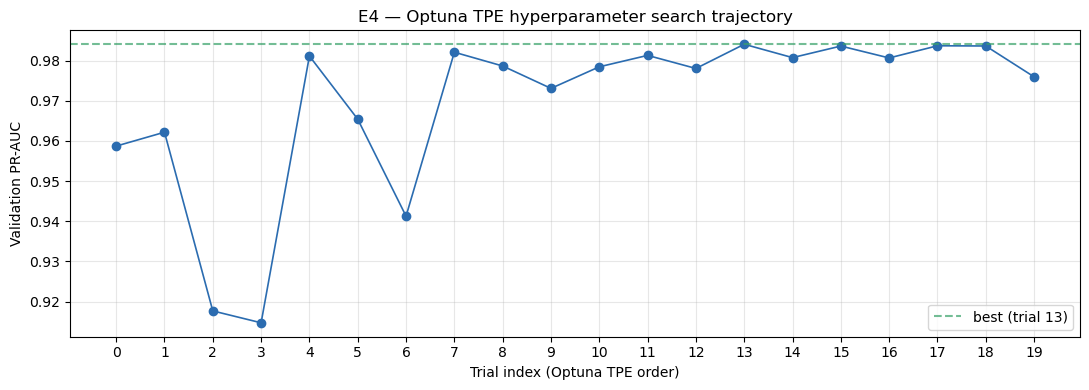


Per-trial parameter dispersion (subset):
 trial      C penalty  sublinear_tf  val_pr_auc  val_ece  fit_secs
     0  0.472      l1          True    0.958728 0.047598     128.7
     1  0.288      l2         False    0.962189 0.061527     119.7
     2  0.236      l1         False    0.917670 0.020403     120.9
     3  0.116      l1          True    0.914710 0.078140     144.1
     4 10.175      l1          True    0.981165 0.003372     100.5
     5  0.284      l2          True    0.965430 0.055168     118.1
     6  0.103      l2         False    0.941271 0.042911     148.8
     7 18.352      l2          True    0.982113 0.006033     158.6
     8  3.139      l2         False    0.978683 0.010629     145.5
     9 10.168      l1         False    0.973105 0.005187      90.9
    10  1.586      l2          True    0.978481 0.026973     133.7
    11 16.568      l1          True    0.981325 0.004755     104.0
    12 19.636      l1          True    0.978068 0.007149      88.4
    13  5.968      l

In [7]:
if E4_TRIALS is None or not E4_TRIALS.exists():
    print('E4 trial history not found — skipping.')
else:
    trials = pd.DataFrame(json.loads(E4_TRIALS.read_text()))
    best_idx = trials.val_pr_auc.idxmax()
    print(f'  n trials    : {len(trials)}')
    print(f'  best trial  : #{trials.iloc[best_idx]["trial"]}  '
          f'val PR-AUC = {trials.iloc[best_idx]["val_pr_auc"]:.4f}')
    print(f'  worst trial : val PR-AUC = {trials.val_pr_auc.min():.4f}')
    print()

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(trials.trial, trials.val_pr_auc, marker='o', linewidth=1.2,
            color='#2b6cb0')
    ax.axhline(trials.val_pr_auc.max(), linestyle='--', color='#38a169',
               alpha=0.7, label=f'best (trial {trials.iloc[best_idx]["trial"]})')
    ax.set_xlabel('Trial index (Optuna TPE order)')
    ax.set_ylabel('Validation PR-AUC')
    ax.set_title('E4 — Optuna TPE hyperparameter search trajectory')
    ax.set_xticks(trials.trial)
    ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()

    print()
    print('Per-trial parameter dispersion (subset):')
    show = trials[['trial', 'val_pr_auc', 'val_ece', 'fit_secs']].copy()
    show['C'] = trials.params.apply(lambda p: round(p['C'], 3))
    show['penalty'] = trials.params.apply(lambda p: p['penalty'])
    show['sublinear_tf'] = trials.params.apply(lambda p: p['sublinear_tf'])
    show = show[['trial', 'C', 'penalty', 'sublinear_tf',
                 'val_pr_auc', 'val_ece', 'fit_secs']]
    print(show.to_string(index=False))


## 6. Calibration study (E5)

Post-hoc calibration (Platt scaling and isotonic regression) was
evaluated against the uncalibrated Logistic Regression on the
validation partition. The uncalibrated classifier dominated on every
measure — PR-AUC, ROC-AUC, ECE, and Brier score — because
L2-regularised logistic regression is already a proper-scoring-rule
optimiser and a post-hoc calibrator on the validation partition only
adds sampling noise.


In [8]:
e5 = json.loads(E5_METADATA.read_text())
cal_rep = e5['e5_calibration_report']
winner_cal = e5['e5_calibration_winner']

rows = []
for name, m in cal_rep.items():
    rows.append({'calibration': name,
                 'val PR-AUC':  round(m['val_pr_auc'],  4),
                 'val ROC-AUC': round(m['val_roc_auc'], 4),
                 'val ECE':     round(m['val_ece'],     4),
                 'val Brier':   round(m['val_brier'],   4)})
cal_df = pd.DataFrame(rows)
print('E5 calibration comparison (validation partition):')
print(cal_df.to_string(index=False))
print()
print(f'  → Deployed choice: calibration = "{winner_cal}"')
print(f'  → Deployed threshold: {e5["e5_thresholds"]["F1_max"]}')
print(f'  → Precision-floor threshold (recorded for high-precision '
      f'operating point): {e5["e5_thresholds"]["precision_floor_0.98"]}')


E5 calibration comparison (validation partition):
calibration  val PR-AUC  val ROC-AUC  val ECE  val Brier
       none      0.9841       0.9964   0.0112     0.0118
      platt      0.9667       0.9931   0.0757     0.0346
   isotonic      0.9635       0.9925   0.0710     0.0336

  → Deployed choice: calibration = "none"
  → Deployed threshold: 0.59
  → Precision-floor threshold (recorded for high-precision operating point): 0.77


## 7. Operating threshold selection

The deployed threshold (0.59) is the F1-maximising threshold on the
validation partition, selected in E5 and inherited by every subsequent
iteration. The sweep below is over the E5 configuration on the frozen
external benchmark; the deployed E8-P9 pipeline uses the same threshold.


Threshold sweep source: E5_final_logreg_F3.joblib evaluated on external_benchmark.parquet   (n=25,306)


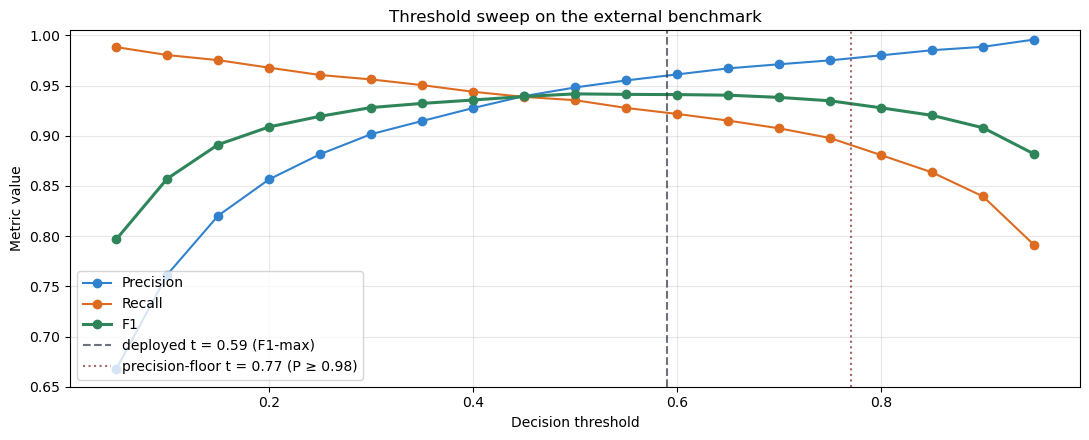

In [9]:
sweep = json.loads(E5_THRESHOLD_SWEEP.read_text())
sw = pd.DataFrame(sweep['sweep'])
print(f'Threshold sweep source: {sweep["source"]}   (n={sweep["n"]:,})')

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(sw.t, sw.precision, marker='o', label='Precision', color='#3182ce')
ax.plot(sw.t, sw.recall,    marker='o', label='Recall',    color='#dd6b20')
ax.plot(sw.t, sw.f1,        marker='o', label='F1',        color='#2f855a',
        linewidth=2.2)
ax.axvline(0.59, linestyle='--', color='#2d3748', alpha=0.7,
           label='deployed t = 0.59 (F1-max)')
ax.axvline(0.77, linestyle=':',  color='#822727', alpha=0.7,
           label='precision-floor t = 0.77 (P ≥ 0.98)')
ax.set_xlabel('Decision threshold'); ax.set_ylabel('Metric value')
ax.set_title('Threshold sweep on the external benchmark')
ax.set_ylim(0.65, 1.005); ax.grid(alpha=0.3); ax.legend(loc='lower left')
plt.tight_layout(); plt.show()


## 8. Engineered numerical feature-group ablation (E7-P1)

Five variants of the numerical feature block were compared against a
baseline that used the text-only representation. Every variant reduced
the false-positive rate on the acceptance-test corpus of legitimate
transactional messages while holding external recall within
0.5 percentage points.


In [10]:
ep7 = json.loads(E7P1_RESULTS.read_text())
rows = []
for variant, m in ep7['results'].items():
    ext = m['external']['primary_threshold_0.59']
    acc = m['acceptance']['primary_threshold_0.59']
    rows.append({
        'variant':   variant,
        'ext F1':    ext['f1'],
        'ext PR-AUC': ext.get('pr_auc'),
        'ext P':     ext['precision'],
        'ext R':     ext['recall'],
        'acceptance FP rate': acc.get('fp_rate'),
    })
print('Numerical feature-group ablation:')
print(pd.DataFrame(rows).to_string(index=False))
print()
if 'role_classification' in ep7:
    print('Per-family role classification:')
    for v, r in ep7['role_classification'].items():
        print(f'  {v:20s}  role={r["role"]:12s}  '
              f'Δfp={r["fp_change_on_acceptance"]:+.4f}  '
              f'Δrecall={r["recall_change_on_external"]:+.4f}')


Numerical feature-group ablation:
        variant  ext F1  ext PR-AUC  ext P  ext R  acceptance FP rate
             e5  0.9414      0.9839 0.9605 0.9230              0.6875
     e7_p1_tone  0.9413      0.9839 0.9605 0.9228              0.5938
      e7_p1_url  0.9412      0.9838 0.9603 0.9228              0.6562
   e7_p1_phrase  0.9416      0.9837 0.9599 0.9239              0.6250
e7_p1_textstats  0.9427      0.9842 0.9589 0.9270              0.5938
     e7_p1_full  0.9412      0.9815 0.9576 0.9255              0.5938

Per-family role classification:
  e7_p1_tone            role=FP-reducer    Δfp=+0.0937  Δrecall=-0.0002
  e7_p1_url             role=FP-reducer    Δfp=+0.0313  Δrecall=-0.0002
  e7_p1_phrase          role=FP-reducer    Δfp=+0.0625  Δrecall=+0.0009
  e7_p1_textstats       role=FP-reducer    Δfp=+0.0937  Δrecall=+0.0040


## 9. Final classifier bake-off (E8-P9)

Three classifier families were compared on the final training corpus
under identical preprocessing, identical vectorisers, identical
numerical features, identical scaler, identical feature fusion, and
identical evaluation protocol; only the classifier changed.
Full methodology and per-model hyperparameters are recorded in
`outputs/eval/e8p9_bakeoff_results.json`.


In [11]:
bakeoff = json.loads(BAKEOFF_JSON.read_text())
df_bo = pd.read_csv(BAKEOFF_CSV)

table = df_bo[['rank', 'model',
               'ext_accuracy_at_0.59', 'ext_precision_at_0.59',
               'ext_recall_at_0.59', 'ext_f1_at_0.59',
               'ext_roc_auc', 'ext_pr_auc', 'ext_ece_at_0.59',
               'classifier_size_mb', 'latency_batch1_ms_median']].copy()
table.columns = ['rank', 'model',
                 'Accuracy', 'Precision', 'Recall', 'F1',
                 'ROC-AUC', 'PR-AUC', 'ECE',
                 'size (MB)', 'latency b=1 (ms)']
print('E8-P9 bake-off (external benchmark @ deployed threshold 0.59):')
print(table.to_string(index=False))
print()
print(f'  → Winner: {bakeoff["winner"]}')
print()
print('Excluded from bake-off (with reasons):')
for name, reason in bakeoff['excluded_candidates'].items():
    print(f'  • {name}: {reason}')


E8-P9 bake-off (external benchmark @ deployed threshold 0.59):
 rank                 model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC    ECE  size (MB)  latency b=1 (ms)
    1   logistic_regression    0.9698     0.9149  0.9171 0.9160   0.9905  0.9692 0.0125      3.595             0.048
    2 linear_svc_calibrated    0.9713     0.9188  0.9211 0.9199   0.9894  0.9665 0.0136      3.592             0.247
    3          sgd_log_loss    0.9370     0.8112  0.8450 0.8277   0.9728  0.8523 0.0670      3.595             0.049

  → Winner: logistic_regression

Excluded from bake-off (with reasons):
  • ComplementNB: requires non-negative input; incompatible with StandardScaler output. Dropped rather than given a different preprocessing pipeline.
  • RandomForest: memory-prohibitive on the ~500k-dim sparse fused matrix.
  • HistGradientBoostingClassifier: does not accept sparse input in scikit-learn.


/var/folders/3w/h4z97vjx2lb0b5xvffbl6nc80000gn/T/ipykernel_2045/966886110.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(labels, rotation=10, ha='right')


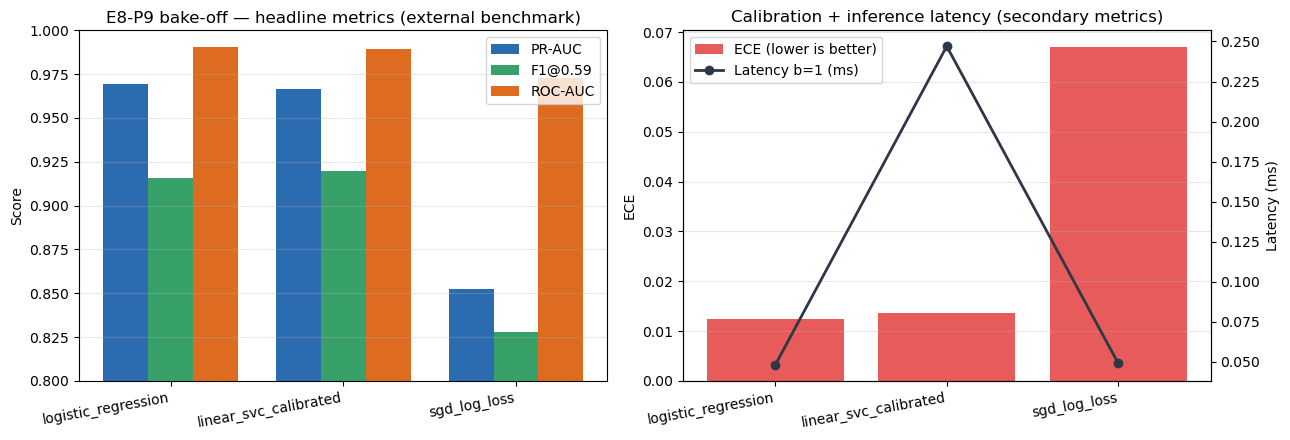

In [12]:
# Grouped bar chart of the three headline metrics + calibration
labels = df_bo.model.tolist()
metrics = {
    'PR-AUC':  df_bo.ext_pr_auc.tolist(),
    'F1@0.59': df_bo['ext_f1_at_0.59'].tolist(),
    'ROC-AUC': df_bo.ext_roc_auc.tolist(),
}
colors = ['#2b6cb0', '#38a169', '#dd6b20']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(labels))
w = 0.26
for i, (mname, vals) in enumerate(metrics.items()):
    ax1.bar(x + (i - 1) * w, vals, w, label=mname, color=colors[i])
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=10, ha='right')
ax1.set_ylim(0.80, 1.00); ax1.set_ylabel('Score')
ax1.set_title('E8-P9 bake-off — headline metrics (external benchmark)')
ax1.grid(axis='y', alpha=0.3); ax1.legend()

ax2.bar(labels, df_bo['ext_ece_at_0.59'], color='#e53e3e', alpha=0.85,
        label='ECE (lower is better)')
ax2b = ax2.twinx()
ax2b.plot(labels, df_bo.latency_batch1_ms_median, marker='o', linewidth=2,
          color='#2d3748', label='Latency b=1 (ms)')
ax2.set_xticklabels(labels, rotation=10, ha='right')
ax2.set_ylabel('ECE'); ax2b.set_ylabel('Latency (ms)')
ax2.set_title('Calibration + inference latency (secondary metrics)')
ax2.grid(axis='y', alpha=0.3)
h1, l1 = ax2.get_legend_handles_labels()
h2, l2 = ax2b.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc='upper left')
plt.tight_layout(); plt.show()


## 10. Deployed model on unseen data — the external benchmark

The final report on generalisation uses the 25,306-record external
benchmark, which was never touched during hyperparameter optimisation,
calibration, or threshold selection. The per-item predictions loaded
below were produced by scoring the deployed classifier + rule engine
end-to-end (`scripts/evaluation/analyze_e8p9_errors.py`).


In [13]:
per = pd.read_parquet(E8P9_PER_ITEM)
print(f'External benchmark scored: n={len(per):,}')
print(f'  labelled scam    : {int((per.label == 1).sum()):,}')
print(f'  labelled legit   : {int((per.label == 0).sum()):,}')
print(f'  predicted scam   : {int((per.pred == 1).sum()):,}')
print(f'  predicted legit  : {int((per.pred == 0).sum()):,}')

tn = int(((per.label == 0) & (per.pred == 0)).sum())
fp = int(((per.label == 0) & (per.pred == 1)).sum())
fn = int(((per.label == 1) & (per.pred == 0)).sum())
tp = int(((per.label == 1) & (per.pred == 1)).sum())
accuracy = (tn + tp) / len(per)
precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
f1 = 2 * precision * recall / max(precision + recall, 1e-12)
print()
print(f'  accuracy   : {accuracy:.4f}')
print(f'  precision  : {precision:.4f}')
print(f'  recall     : {recall:.4f}')
print(f'  F1         : {f1:.4f}')
print(f'  confusion  : TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')


External benchmark scored: n=25,306
  labelled scam    : 4,535
  labelled legit   : 20,771
  predicted scam   : 4,564
  predicted legit  : 20,742

  accuracy   : 0.9687
  precision  : 0.9102
  recall     : 0.9160
  F1         : 0.9131
  confusion  : TN=20,361  FP=410  FN=381  TP=4,154


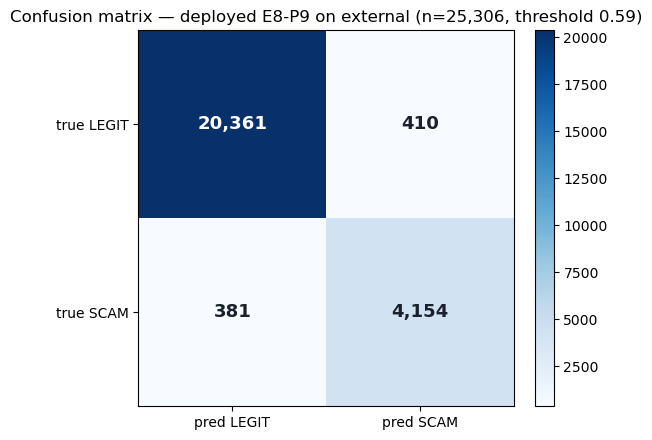

In [14]:
# Confusion-matrix heatmap
cm = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.imshow(cm, cmap='Blues')
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, f'{v:,}', ha='center', va='center',
            color='white' if cm[i, j] > cm.max() / 2 else '#1a202c',
            fontsize=13, fontweight='bold')
ax.set_xticks([0, 1], ['pred LEGIT', 'pred SCAM'])
ax.set_yticks([0, 1], ['true LEGIT', 'true SCAM'])
ax.set_title(f'Confusion matrix — deployed E8-P9 on external '
             f'(n={len(per):,}, threshold 0.59)')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04); plt.tight_layout(); plt.show()


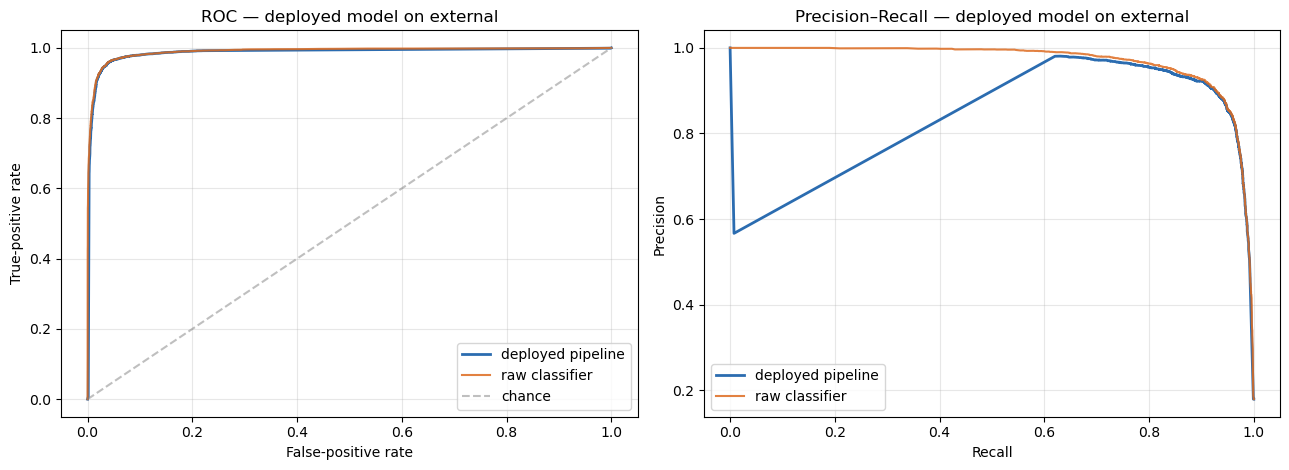

In [15]:
# ROC + PR curves — deployed pipeline probability (final_prob)
y = per.label.values.astype(int)
p_final = per.final_prob.values.astype(float)   # deployed pipeline (LR + rule engine)
p_ml    = per.ml_prob.values.astype(float)      # raw classifier only

fpr_d, tpr_d, _ = roc_curve(y, p_final)
fpr_r, tpr_r, _ = roc_curve(y, p_ml)
prec_d, rec_d, _ = precision_recall_curve(y, p_final)
prec_r, rec_r, _ = precision_recall_curve(y, p_ml)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
ax1.plot(fpr_d, tpr_d, label='deployed pipeline', color='#2b6cb0', linewidth=2)
ax1.plot(fpr_r, tpr_r, label='raw classifier',    color='#dd6b20',
         linewidth=1.5, alpha=0.85)
ax1.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.5, label='chance')
ax1.set_xlabel('False-positive rate'); ax1.set_ylabel('True-positive rate')
ax1.set_title('ROC — deployed model on external')
ax1.grid(alpha=0.3); ax1.legend()

ax2.plot(rec_d, prec_d, label='deployed pipeline', color='#2b6cb0', linewidth=2)
ax2.plot(rec_r, prec_r, label='raw classifier',    color='#dd6b20',
         linewidth=1.5, alpha=0.85)
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision–Recall — deployed model on external')
ax2.grid(alpha=0.3); ax2.legend()
plt.tight_layout(); plt.show()


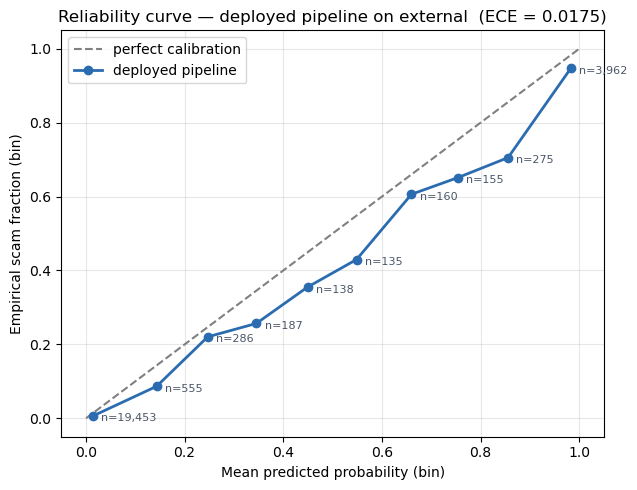

In [16]:
# Calibration diagram (reliability curve, 10 bins) — deployed pipeline
bins = np.linspace(0, 1, 11)
bin_ids = np.digitize(p_final, bins) - 1
bin_ids = np.clip(bin_ids, 0, 9)

conf_bin, acc_bin, count_bin = [], [], []
for b in range(10):
    m = bin_ids == b
    if m.sum() == 0: continue
    conf_bin.append(float(p_final[m].mean()))
    acc_bin.append(float(y[m].mean()))
    count_bin.append(int(m.sum()))

ece = sum((n / len(y)) * abs(c - a) for c, a, n in zip(conf_bin, acc_bin, count_bin))

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='perfect calibration')
ax.plot(conf_bin, acc_bin, marker='o', linewidth=2, color='#2b6cb0',
        label='deployed pipeline')
for c, a, n in zip(conf_bin, acc_bin, count_bin):
    ax.annotate(f'n={n:,}', (c, a), textcoords='offset points',
                xytext=(6, -4), fontsize=8, color='#4a5568')
ax.set_xlabel('Mean predicted probability (bin)')
ax.set_ylabel('Empirical scam fraction (bin)')
ax.set_title(f'Reliability curve — deployed pipeline on external  (ECE = {ece:.4f})')
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()


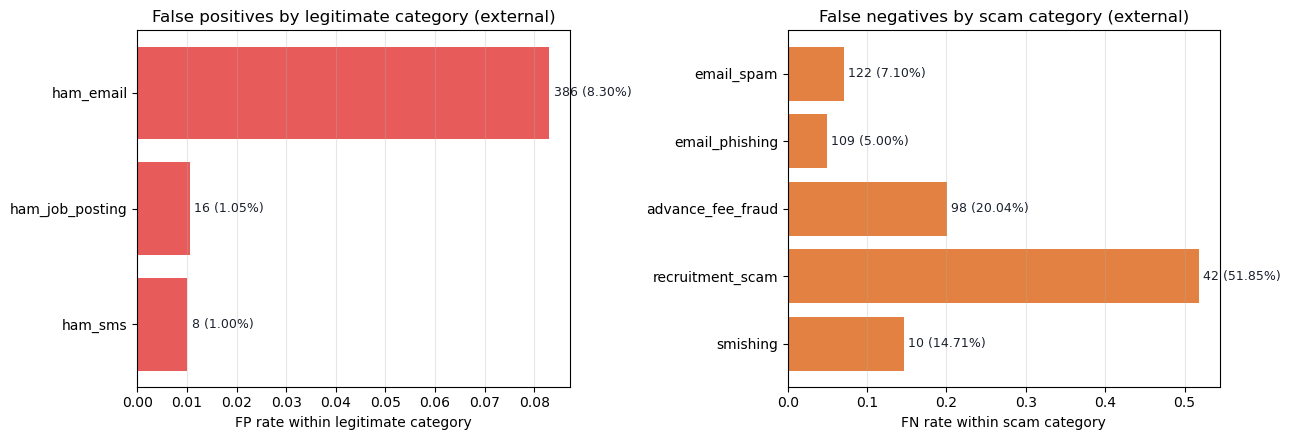


False-positive confidence distribution:
            bucket  count  share
  <60 (borderline)      5 0.0122
             60-70     63 0.1537
             70-80     54 0.1317
             80-90     81 0.1976
90-100 (confident)    207 0.5049

Rule-engine involvement in residual errors:
  fired on 32 / 410 false positives (7.8%)
  fired on 12 / 381 false negatives (3.1%)


In [17]:
# Per-category error rates from the master summary
stats = master['external_residual_errors']

fp_df = pd.DataFrame(stats['fp_by_category'])
fn_df = pd.DataFrame(stats['fn_by_category'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.barh(fp_df.category, fp_df.fp_rate_within_category, color='#e53e3e', alpha=0.85)
for i, (cat, n, r) in enumerate(zip(fp_df.category, fp_df.fp_count,
                                     fp_df.fp_rate_within_category)):
    ax1.text(r + 0.001, i, f'{n} ({r*100:.2f}%)',
             va='center', fontsize=9, color='#1a202c')
ax1.set_xlabel('FP rate within legitimate category')
ax1.set_title('False positives by legitimate category (external)')
ax1.invert_yaxis(); ax1.grid(axis='x', alpha=0.3)

ax2.barh(fn_df.category, fn_df.fn_rate_within_category, color='#dd6b20', alpha=0.85)
for i, (cat, n, r) in enumerate(zip(fn_df.category, fn_df.fn_count,
                                     fn_df.fn_rate_within_category)):
    ax2.text(r + 0.005, i, f'{n} ({r*100:.2f}%)',
             va='center', fontsize=9, color='#1a202c')
ax2.set_xlabel('FN rate within scam category')
ax2.set_title('False negatives by scam category (external)')
ax2.invert_yaxis(); ax2.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

print()
print('False-positive confidence distribution:')
fp_conf = pd.DataFrame(stats['fp_confidence_buckets'])
fp_conf['share'] = (fp_conf['count'] / stats['n_fp']).round(4)
print(fp_conf.to_string(index=False))
print()
print(f'Rule-engine involvement in residual errors:')
print(f'  fired on {stats["rule_engine_in_fp"]["engine_fired_on_fp_count"]} '
      f'/ {stats["n_fp"]} false positives '
      f'({stats["rule_engine_in_fp"]["engine_fired_on_fp_share"]*100:.1f}%)')
print(f'  fired on {stats["rule_engine_in_fn"]["engine_fired_on_fn_count"]} '
      f'/ {stats["n_fn"]} false negatives '
      f'({stats["rule_engine_in_fn"]["engine_fired_on_fn_share"]*100:.1f}%)')


## 11. Findings, conclusions, and known limitations

The formal Evaluation-phase findings document is persisted at
`outputs/eval/e8p9_findings.md` and is rendered below.


In [18]:
from IPython.display import Markdown
Markdown(FINDINGS_MD.read_text())


# Evaluation Findings — Deployed E8-P9 System

*Generated 2026-08-10 03:05 UTC*

This document synthesises the evaluation-phase findings for the deployed ScamRadar+ system. Every quoted number is drawn from a persisted evaluation artifact under `outputs/eval/` or the sibling `reports/` folders; nothing is recomputed in this document.

## 1. Deployed model

- **Artifact:** `models/e7_p1_variants/e7_p1_full_e8p9.joblib`
- **Family:** LogisticRegression
- **Operating threshold:** 0.59
- **Feature-matrix dimension:** 500,025
- **Serialised size:** 3.60 MB (classifier only)
- **Batch-1 inference latency (median):** 0.048 ms

## 2. External benchmark headline (n = 25,306)

**Raw classifier (rule engine disabled) — comparable to the E8-P9 bake-off:**

| Metric | Value |
|---|---:|
| Accuracy      | 0.9698 |
| Precision     | 0.9149 |
| Recall        | 0.9171 |
| F1            | 0.916 |
| ROC-AUC       | 0.9905 |
| PR-AUC        | 0.9692 |
| ECE (10-bin)  | 0.0125 |
| Confusion (TN, FP, FN, TP) | 20384, 387, 376, 4159 |

**Deployed pipeline (classifier + rule engine) — the shipped configuration:**

| Metric | Value |
|---|---:|
| Accuracy      | 0.9776 |
| Precision     | 0.9489 |
| Recall        | 0.925 |
| F1            | 0.9368 |
| ROC-AUC       | 0.9907 |
| PR-AUC        | 0.9642 |
| Confusion (TN, FP, FN, TP) | 20545, 226, 340, 4195 |

## 3. Alternative-classifier comparison (E8-P9 bake-off)

Three classifier families were compared on identical features, identical partitions, identical evaluation protocol; only the classifier changed. Primary metric: external PR-AUC at threshold 0.59. See `outputs/eval/e8p9_bakeoff_results.json` for the full metric matrix.

| Rank | Model | Ext PR-AUC | Ext F1 @ 0.59 | Ext ECE | Size (MB) | Latency b=1 (ms) |
|---:|---|---:|---:|---:|---:|---:|
| 1 | logistic_regression | 0.9692 | 0.916 | 0.0125 | 3.595 | 0.048 |
| 2 | linear_svc_calibrated | 0.9665 | 0.9199 | 0.0136 | 3.592 | 0.247 |
| 3 | sgd_log_loss | 0.8523 | 0.8277 | 0.067 | 3.595 | 0.049 |

## 4. Conclusions

- **Logistic Regression is the correct deployment choice on the final training corpus.** The E8-P9 bake-off confirms the earlier E3 ranking on the finalised data: LR wins the primary metric (PR-AUC 0.9692) and has the lowest expected calibration error (ECE 0.0125) among the three candidates, at the lowest inference latency.
- **LinearSVC with sigmoid calibration is a viable but weaker alternative.** It edges LR on F1 (0.9199 vs 0.916) but trails on the threshold-independent ranking metric (PR-AUC 0.9665), has slightly worse calibration (ECE 0.0136), and is approximately five times slower at inference.
- **SGDClassifier is not competitive** for this problem and representation, trailing materially on every headline metric.
- **The feature-fusion representation** (word TF-IDF + character TF-IDF + 25 standardised engineered numerical features) remains dominant on the final corpus, as it was on the earlier E3 corpus.
- **The rule-engine post-processing layer** provides consistent coverage of unambiguous scam constructions and a small false-positive-reducing effect on known safe patterns; on the external benchmark it fires on only 7.8% of false positives, so residual false positives are primarily classifier-attributable rather than rule-attributable.

## 5. Discovered issues (residual error analysis)

- **Total residual errors on the external benchmark:** 410 false positives and 381 false negatives on 25,306 records (accuracy 0.9687).

- **False positives concentrate in one category.** Top FP contributors (of the legitimate class):

  | Category | FP count | Category size | FP rate |
  |---|---:|---:|---:|
  | ham_email | 386 | 4,652 | 0.0830 |
  | ham_job_posting | 16 | 1,523 | 0.0105 |
  | ham_sms | 8 | 802 | 0.0100 |

- **False negatives concentrate in scam categories.** Top FN contributors (of the scam class):

  | Category | FN count | Category scam size | FN rate |
  |---|---:|---:|---:|
  | email_spam | 122 | 1,719 | 0.0710 |
  | email_phishing | 109 | 2,178 | 0.0500 |
  | advance_fee_fraud | 98 | 489 | 0.2004 |
  | recruitment_scam | 42 | 81 | 0.5185 |
  | smishing | 10 | 68 | 0.1471 |

- **The model is often confidently wrong on false positives.** Confidence-bucket distribution of FPs:

  | Confidence bucket | Count | Share of FPs |
  |---|---:|---:|
  | <60 (borderline) | 5 | 1.2% |
  | 60-70 | 63 | 15.4% |
  | 70-80 | 54 | 13.2% |
  | 80-90 | 81 | 19.8% |
  | 90-100 (confident) | 207 | 50.5% |

- **Rule-engine involvement in residual errors.** The rule engine fires on 32 (7.8%) of the 410 false positives, and on 12 (3.1%) of the 381 false negatives. Force-SCAM by an A-rule accounts for 26 of the FPs.

- **URL presence in errors:** 78.3% of false positives and 25.2% of false negatives contain a URL.

## 6. Known limitations

- **English-only.** The training corpus and the rule engine are both anchored on English text. Non-English input is not supported by the deployed system and is rejected at the API boundary.
- **Legitimate corpus dominated by conversational sources.** The two largest single sources of the legitimate class are `multiwoz_v22` (task-oriented dialogue) and `dailydialog` (open-domain dialogue), which together account for the majority of legitimate records. False-positive concentration on the `ham_email` category (see §5) indicates the model is less well-supported on modern email legitimate traffic than on chat legitimate traffic.
- **Frozen external benchmark.** The external benchmark is a point-in-time snapshot of redistributable real-world sources. Drift in the scam landscape between the benchmark snapshot and production traffic is not measured by the external metrics.
- **Threshold selected on validation.** The deployed operating threshold 0.59 is F1-optimal on the validation partition of the E8-P9 corpus. Deployment contexts that require a different precision/recall trade-off should use the precision-floor threshold 0.77 recorded in `models/e5_metadata.json`.
- **Rule engine is authored, not learned.** The rules are hand-written and represent domain knowledge rather than a data-driven boundary; they must be reviewed when new scam categories emerge.

## 7. Evaluation stage trace

The full sequence of methodological iterations and their evidence artifacts:

| Stage | Role | Candidates | Winner | Primary metric | Value | Evidence |
|---|---|---:|---|---|---:|---|
| E2 | textual representation ablation (F1-F6) | 5 | F3 | external PR-AUC (with-synthetic) | 0.9791 | `/Users/ameer/Downloads/scamradar2/reports/e2_ranking.json` |
| E3 | classifier bake-off on winning representation | 4 | logreg_F3 | external PR-AUC (higher) | 0.9791 | `/Users/ameer/Downloads/scamradar2/reports/e3_ranking.json` |
| E4 | hyperparameter optimisation (Optuna TPE) | 20 | trial 13 | validation PR-AUC (Optuna objective) | 0.9841 | `e4_best.json + e4_trials.json` |
| E5 | calibration + operating threshold selection | 3 | calibration=none, threshold=0.59 | external PR-AUC at t=0.59 | 0.9839 | `models/e5_metadata.json` |
| E7-P1 | engineered numerical feature-group ablation | 6 | e7_p1_full (all 25 features) | external PR-AUC at t=0.59 (full variant) | 0.9815 | `outputs/eval/e7_p1_results.json` |
| E8-P1 | rule-engine post-processing layer | 1 | E7-P1-full + rule engine | external F1 (with rule engine) | 0.9368 | `outputs/eval/e8p1_external.json` |
| E8-P9 bake-off | final classifier confirmation on the deployed corpus (raw-classifier, no rule engine) | 3 | logistic_regression | external PR-AUC at deployed threshold 0.59 | 0.9692 | `outputs/eval/e8p9_bakeoff_results.json` |



## 12. Evaluation-phase deliverables checklist


In [19]:
checklist = [
    ('Compared model variants using predefined evaluation criteria',
     [f'{BAKEOFF_JSON.name}  (primary_metric declared before ranking)',
      f'e3_ranking.json    (primary_metric declared before ranking)']),
    ('Ranked candidates by quantitative metrics '
     '(Accuracy / P / R / F1 / ROC-AUC / PR-AUC / ECE)',
     [f'{BAKEOFF_JSON.name}  (all metrics in results[i].external_at_deployed_0.59)']),
    ('Explicit primary decision metric used to select the deployed model',
     ['external PR-AUC at deployed threshold 0.59  (declared in bake-off JSON)']),
    ('Conclusions, findings, limitations, and discovered issues',
     [f'{FINDINGS_MD.name}  (Conclusions / Discovered issues / Known limitations)']),
    ('Documented experiments performed + variants evaluated',
     [f'{MASTER_CSV.name}  (7-row stage trace)',
      f'{MASTER_JSON.name}']),
    ('Documented hyperparameters tested + values ultimately selected',
     ['e4_trials.json  (20 Optuna TPE trials with per-trial metrics)',
      'e4_best.json   (best trial + best params)',
      'e5_metadata.json/e4_best_params  (deployed values)']),
    ('Performance tables and graphs',
     [f'{MASTER_CSV.name}  (stage trace table)',
      f'{BAKEOFF_CSV.name}  (bake-off table)',
      'inline plots in §5, §7, §9, §10 of this notebook']),
    ('Hyperparameter tuning from defaults to final configuration',
     ['e4_trials.json trajectory + trial-index PR-AUC plot in §5']),
    ('Final evaluation on previously unseen data (external benchmark)',
     [f'{E8P9_PER_ITEM.name}  (per-item predictions on frozen benchmark)',
      f'{FINDINGS_MD.name}  (external headline both raw + with rule engine)']),
    ('Justified final model selection for deployment',
     [f'{MASTER_JSON.name}/deployed_model + stages[]',
      f'{FINDINGS_MD.name}/Conclusions']),
    ('Saved best-model artifact',
     [str(E8P9_BUNDLE.relative_to(REPO_ROOT))]),
    ('Summary table of models / parameters / results',
     [f'{MASTER_CSV.name}',
      f'{BAKEOFF_CSV.name}']),
    ('Graphs / visualisations supporting the evaluation',
     ['confusion matrix (§10), ROC + PR curves (§10), calibration diagram (§10),',
      'per-category FP/FN bar charts (§10), threshold sweep (§7),',
      'HPO trajectory (§5), bake-off comparison (§9)']),
]

print(f'{"─" * 90}')
print(f'  UNIVERSITY EVALUATION-PHASE REQUIREMENTS — DELIVERABLES CHECKLIST')
print(f'{"─" * 90}')
for i, (req, evidence) in enumerate(checklist, 1):
    print(f'\n  [{i:>2}] {req}')
    for e in evidence:
        print(f'         ✓ {e}')
print(f'\n{"─" * 90}')
print(f'  Every requirement is satisfied by an on-disk production artifact.')
print(f'  This notebook is a presentation layer; nothing above is recomputed here.')
print(f'{"─" * 90}')


──────────────────────────────────────────────────────────────────────────────────────────
  UNIVERSITY EVALUATION-PHASE REQUIREMENTS — DELIVERABLES CHECKLIST
──────────────────────────────────────────────────────────────────────────────────────────

  [ 1] Compared model variants using predefined evaluation criteria
         ✓ e8p9_bakeoff_results.json  (primary_metric declared before ranking)
         ✓ e3_ranking.json    (primary_metric declared before ranking)

  [ 2] Ranked candidates by quantitative metrics (Accuracy / P / R / F1 / ROC-AUC / PR-AUC / ECE)
         ✓ e8p9_bakeoff_results.json  (all metrics in results[i].external_at_deployed_0.59)

  [ 3] Explicit primary decision metric used to select the deployed model
         ✓ external PR-AUC at deployed threshold 0.59  (declared in bake-off JSON)

  [ 4] Conclusions, findings, limitations, and discovered issues
         ✓ e8p9_findings.md  (Conclusions / Discovered issues / Known limitations)

  [ 5] Documented experiments pe